<center> <font size = 10> Machine Learning 2 - EasyVisa </center> </font>

# **Problem statement**

**Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.



**Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Data Description**

case_id: ID of each visa application</br>
continent: Information of continent the employee</br>
education_of_employee: Information of education of the employee</br>
has_job_experience: Does the employee have any job experience? Y= Yes; N = No</br>
requires_job_training: Does the employee require any job training? Y = Yes; N = No</br>
no_of_employees: Number of employees in the employer's company</br>
yr_of_estab: Year in which the employer's company was established</br>
region_of_employment: Information of foreign worker's intended region of employment in the US.</br>
prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.</br>
unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.</br>
full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position</br>
case_status: Flag indicating if the Visa was certified or denied

# **Installing and Importing Necessary Libraries and functions**

In [88]:
# This will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading the dataset**

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
df = pd.read_csv('/content/drive/MyDrive/Python/EasyVisa.csv')

# **Data Overview**

This gives us a basic and important information of our dataset.  The initial
steps to understand a dataset is to:

* Observe the first few rows of the dataset to check whether the
dataset is loaded properly or not.
* Get information about the rows and columns in the dataset.
* Find out the data types and non-null value counts of the column .
* Check the statistical summary of the dataset to get an overview of
the numerical columns of the data.

## Displaying the first few rows of the dataset

In [91]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


*  The dataset is loaded succesfully.
*  The dataset provides information about employee education, job experience, continent. Also it provideds information about the wage, unit of wage.

## Checking the shape of the dataset

In [92]:
df.shape

(25480, 12)

The dataset consists of 25480 rows and 12 columns.


## Checking the data types of the columns for the dataset

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


*  There are three numeric variables(float and int) and nine object type variables.
*  The target variable is `case_status` which is of object type.

## Statistical summary of the dataset

In [94]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Exploratory Data Analysis**

In [95]:
def histogram_boxplot(data, feature, figsize=(10, 8), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    f2.suptitle(f"Distribution of {feature}", fontsize=16, fontweight='bold')
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="purple", linestyle="-"
    )  # Add median to the histogram

In [96]:
# function to create labeled barplots
def labeled_barplot(data, feature, hue_column=None, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    hue_column: column to use for hue (default is None, meaning feature will be used for hue)
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=hue_column if hue_column else feature, # Use hue_column if provided, else use feature for hue
        palette="Paired",
        order=sorted(data[feature].unique())[:n] if n else sorted(data[feature].unique()),
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage
    plt.title(f"Distribution of {feature}", fontsize=14, fontweight='bold')
    plt.show()  # show the plot

In [97]:
def stacked_barplot(data, predictor, target, perc=False):
    """
    Print the category counts and plot a stacked bar chart with percentages

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    ax = tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    for c in ax.containers:
        # Customize the labels of the bars.
        labels = [
            f'{v.get_height()*100:.1f}%'
            if v.get_height() > 0
            else '' for v in c
        ]
        ax.bar_label(c, labels=labels, label_type='center')

    plt.title(f"Distribution of {target} by {predictor}", fontsize=14, fontweight='bold')
    plt.show()

In [98]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis

### Distribution of `no_of_employees`

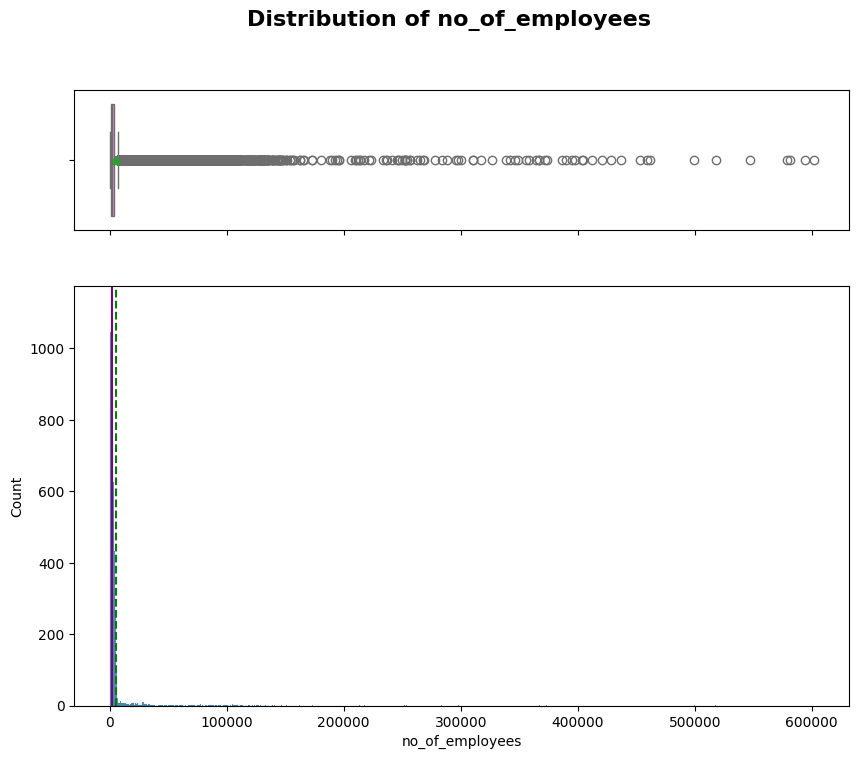

In [99]:
histogram_boxplot(df, "no_of_employees")

*  No of employees distribution is heavily right skewed.
*  There are some extreme outliers which implies that some companies have exceptionally large employee counts.
*  Most observations are concentrated at low employee counts.

### Distribution of `yr_of_estab`

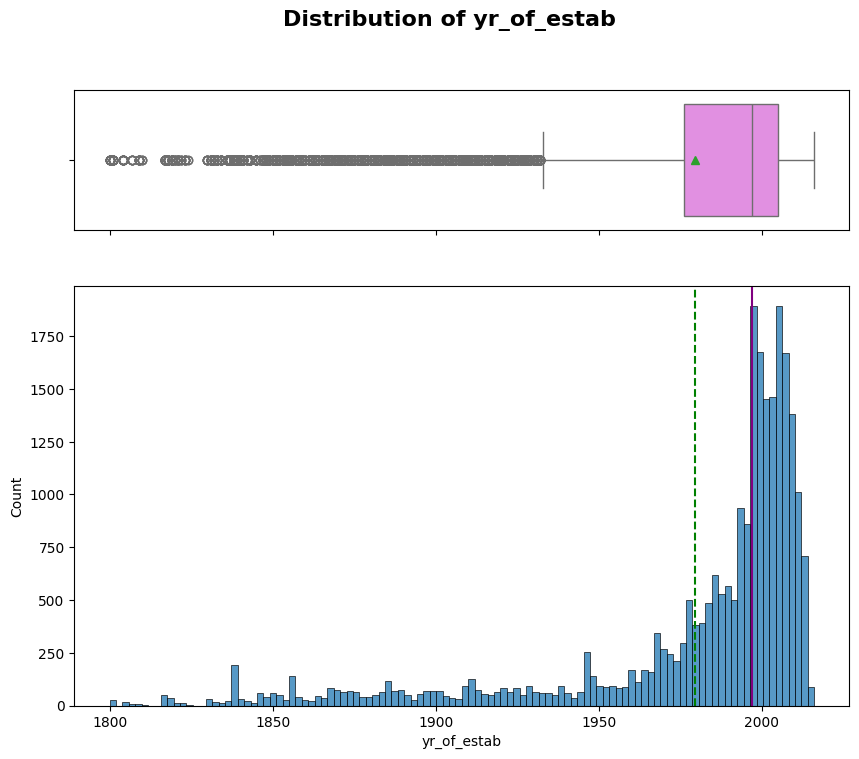

In [100]:
histogram_boxplot(df, "yr_of_estab")

*  The distribution of year of establishment is heavily left skewed.
*  Most of the companies were established in the year 2000.
*  There are some low outliers which implies company establishment around the year 1800.

### Distribution of `prevailing_wage`

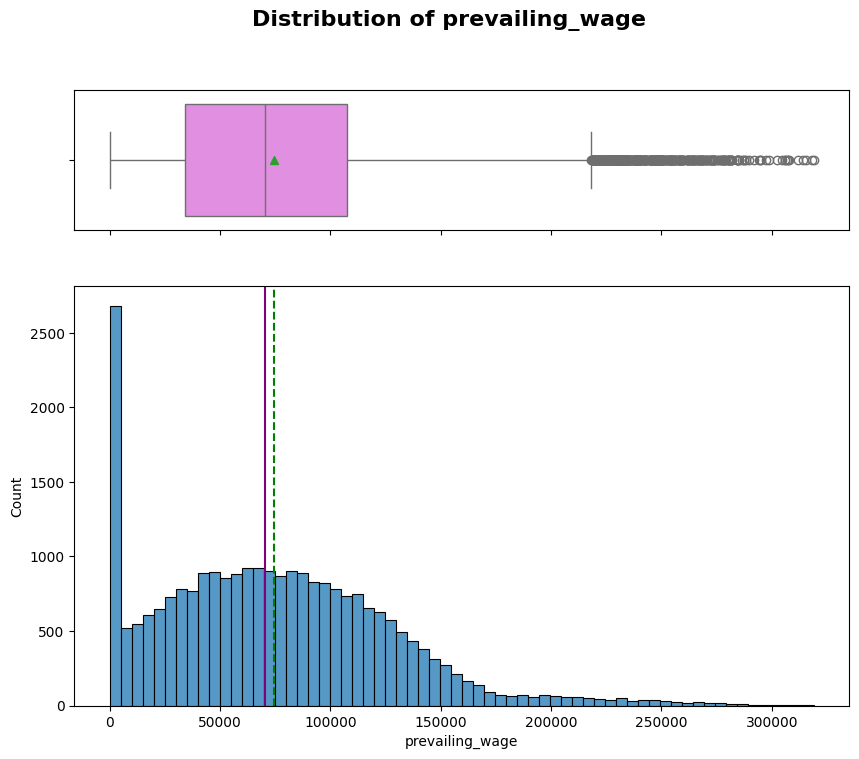

In [101]:
histogram_boxplot(df, "prevailing_wage")

*  The distribution of prevailing wage is right skewed.
*  Most wages are concentrated in the lower-to-mid salary range.
*  Some high value wages are shown as outliers.

### Distribution of `continent`

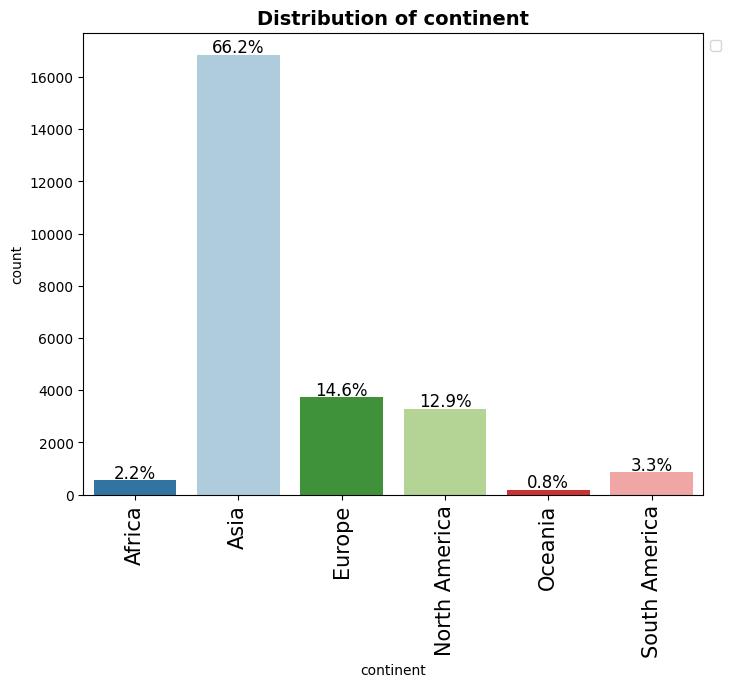

In [102]:
labeled_barplot(df, 'continent', perc=True)
plt.show()

* Asis has the highest count with 66.2%.
*  Europe and North America form a secondary group with moderate representation.
*  The distribution shows class imbalance across continents.

### Distribution of `education_of_employee`

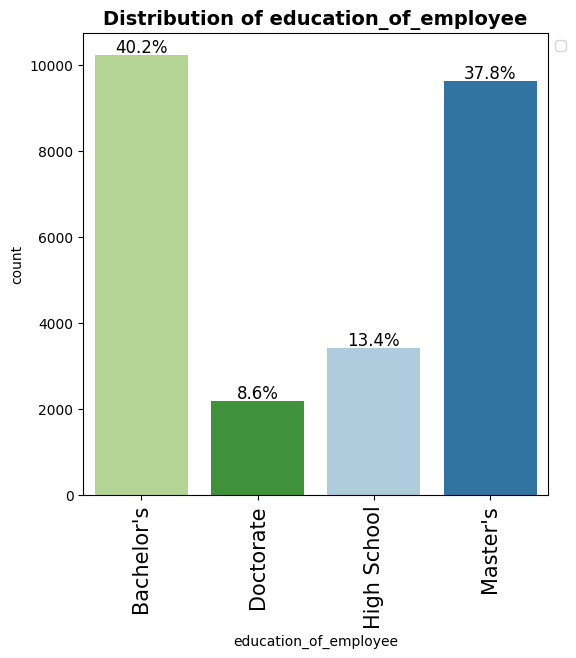

In [103]:
labeled_barplot(df, 'education_of_employee', perc=True)
plt.show()

*  40.2% of the employee have bachelor's degree.
*  Around 37.8% of the employees have Master's degree.
*  Employee who have completed high school is 13.4%.
*  Doctorate employees are least at 8.6%.

### Distribution of `has_job_experience`

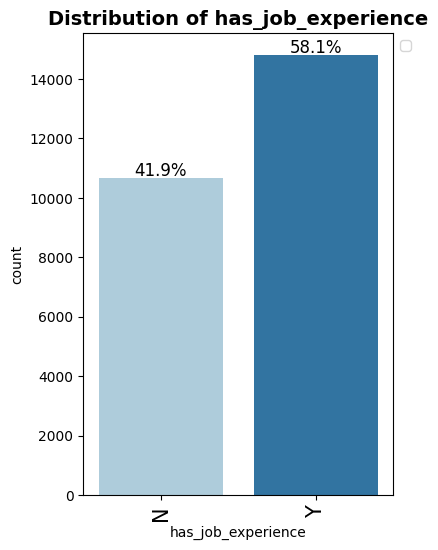

In [104]:
labeled_barplot(df, 'has_job_experience', perc=True)
plt.show()

*  58.1% employees have job experience while 41.9% employee do not have job experience.


### Distribution of `requires_job_training`

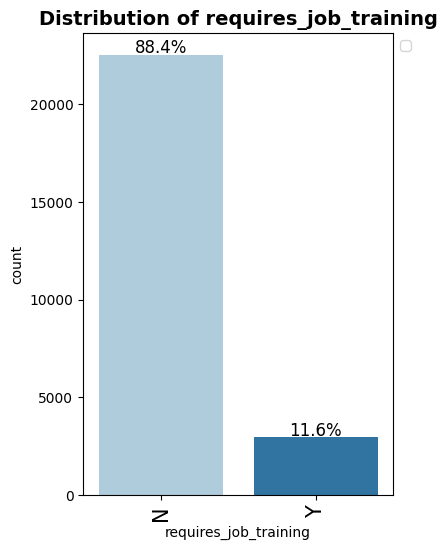

In [105]:
labeled_barplot(df, 'requires_job_training', perc=True)
plt.show()

*  11.6% of the employees required job training.
*  88.4% of the employees do not require job training.

### Distribution of `region_of_employment`

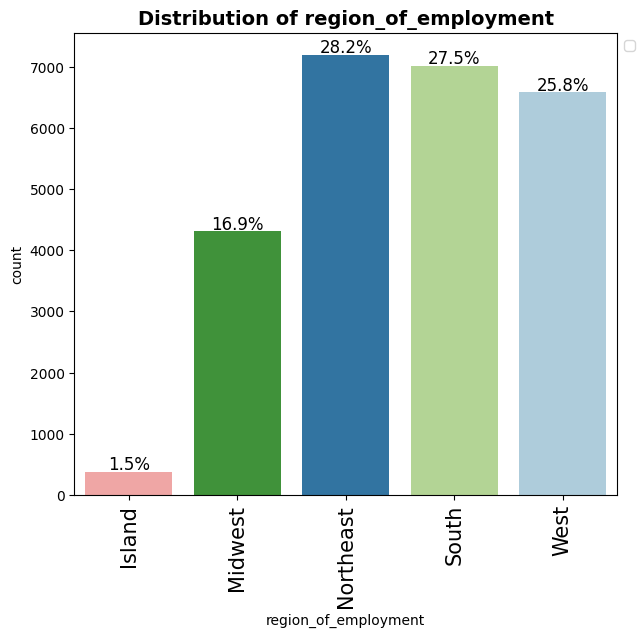

In [106]:
labeled_barplot(df, 'region_of_employment', perc=True)
plt.show()

*  Most of the employees are intended to work in Northeast at 28.2%, followed by south at 27.2% and west region by 25.8%.
*  16.9% of the employees are intended to work in Midwest region.
*  Only 1.5% of the employees are intended to work in Island.


### Distribution of `unit_of_wages`

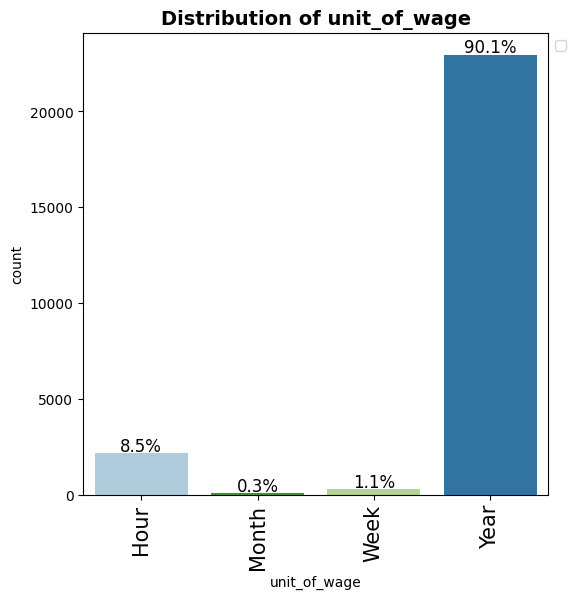

In [107]:
labeled_barplot(df, 'unit_of_wage', perc=True)
plt.show()

*  The vast majority of wages are reported on a yearly basis (~90%), making it the dominant unit.
*  Hourly wages account for 8.5%.
*  Monthly and weekly wages account small for 0.3% and 1.1%.

### Distribution of `full_time_position`

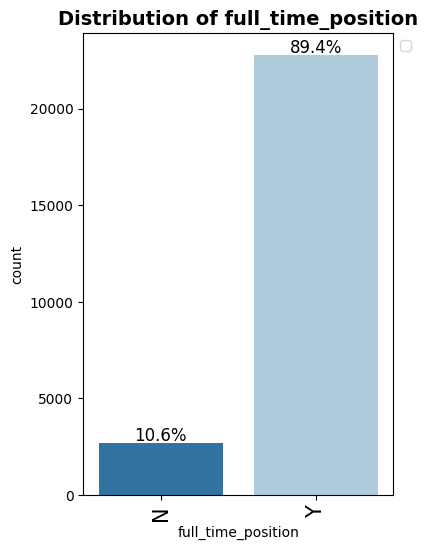

In [108]:
labeled_barplot(df, 'full_time_position', perc=True)
plt.show()

*  89.4% of the employees are positioned for full time work.
*  10.6% of the employees are positioned for part-time.

### Distribution of `case_status`

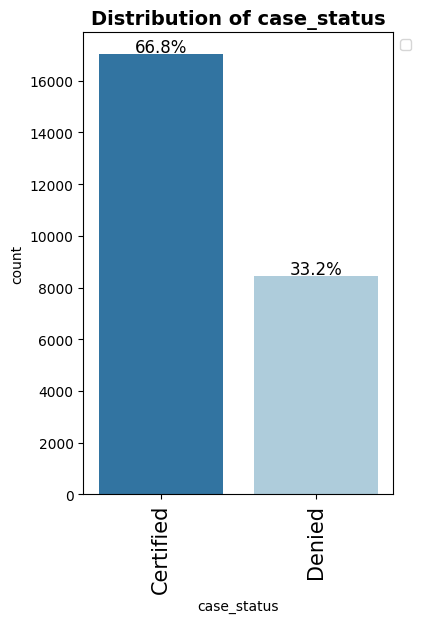

In [109]:
labeled_barplot(df, 'case_status', perc=True)
plt.show()

*  66.8% of the employees were certified with visa.
*  33.2% of the employees were denied visa.

## Bivariate analysis

### Pairplot

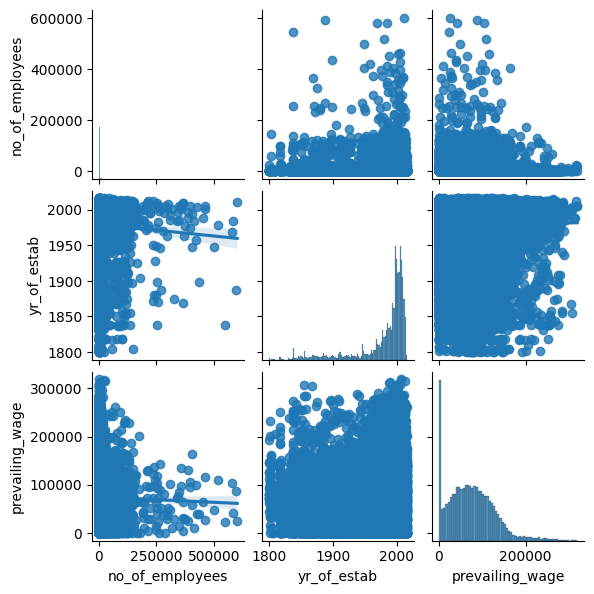

In [110]:
sns.pairplot(data=df, height=2, aspect=1, kind='reg')
plt.show()

###Heatmap

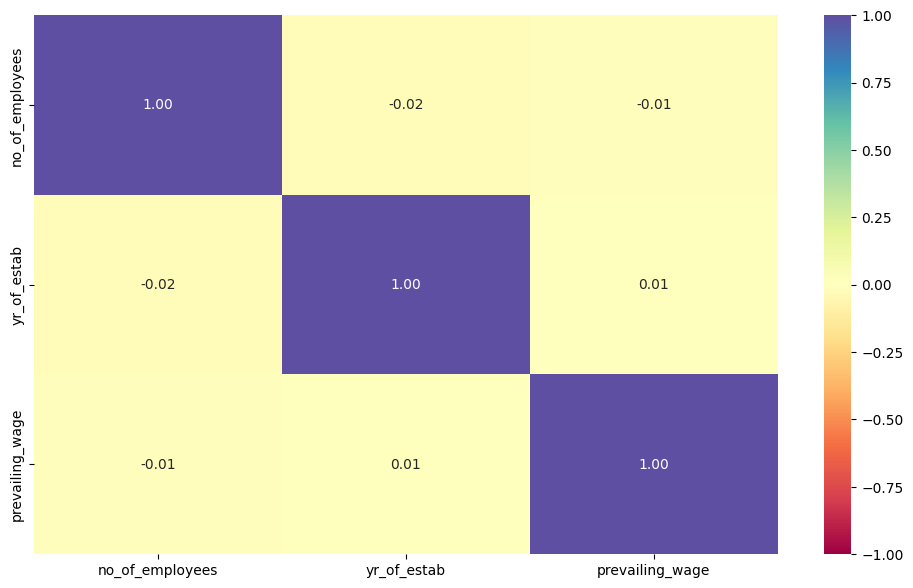

In [111]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1,fmt='.2f', cmap='Spectral')
plt.show()

*  There is no correlation between numerical variables.

### No of employees vs prevailing wage.

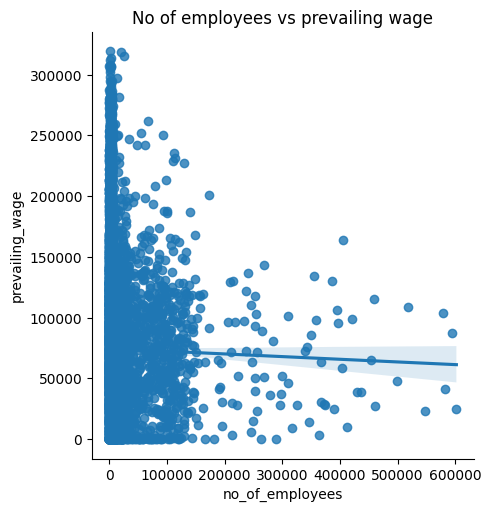

In [112]:
sns.lmplot(df, x='no_of_employees', y='prevailing_wage')
plt.title('No of employees vs prevailing wage')
plt.show()

*  There is a slightly negative correlation between no of employees and prevailing wage.
*  As the number of employees increases, prevailing wage decreases.

### No of employees vs yr of estab

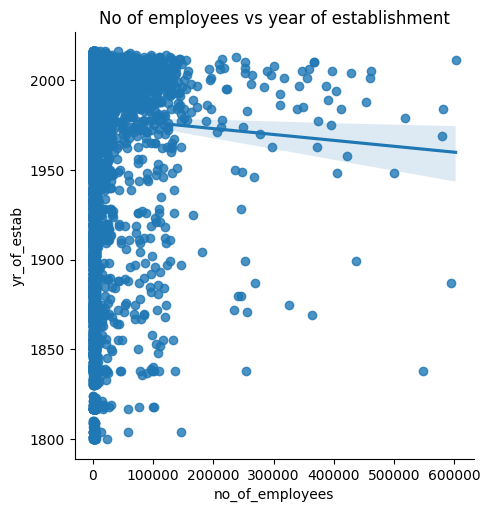

In [113]:
sns.lmplot(df, x='no_of_employees', y='yr_of_estab')
plt.title('No of employees vs year of establishment')
plt.show()

*  There is a slightly negative correlation between no of employees and year of establishment.
*  Most companies are small in size, regardless of when they were established.

### Continent vs region of employment

region_of_employment  Island  Midwest  Northeast  South  West    All
continent                                                           
All                      375     4307       7195   7017  6586  25480
Asia                     226     3371       4589   4805  3870  16861
North America             82      392       1114    870   834   3292
Europe                    32      303        965    973  1459   3732
South America             23      111        266    223   229    852
Africa                     8       92        212    102   137    551
Oceania                    4       38         49     44    57    192
------------------------------------------------------------------------------------------------------------------------


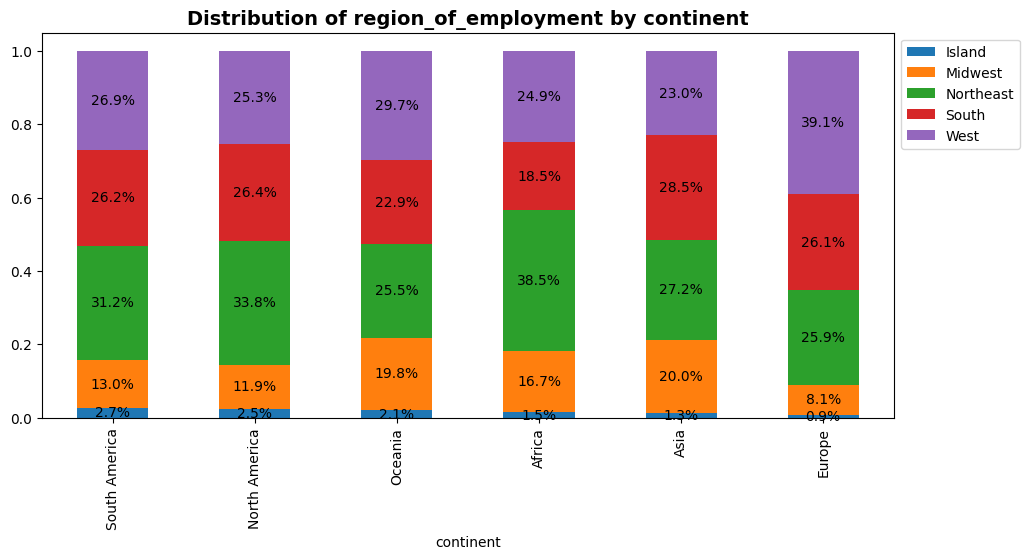

In [114]:
stacked_barplot(df, "continent", "region_of_employment")

*  The West region has a strong presence across all continents and is dominant in Europe.
*  The Island region has the least presence across all continent and is dominent in South America.
*  Northeast region is dominant in Africa, North America and South America.


### Has job experience vs requires job training

requires_job_training      N     Y    All
has_job_experience                       
All                    22525  2955  25480
N                       8988  1690  10678
Y                      13537  1265  14802
------------------------------------------------------------------------------------------------------------------------


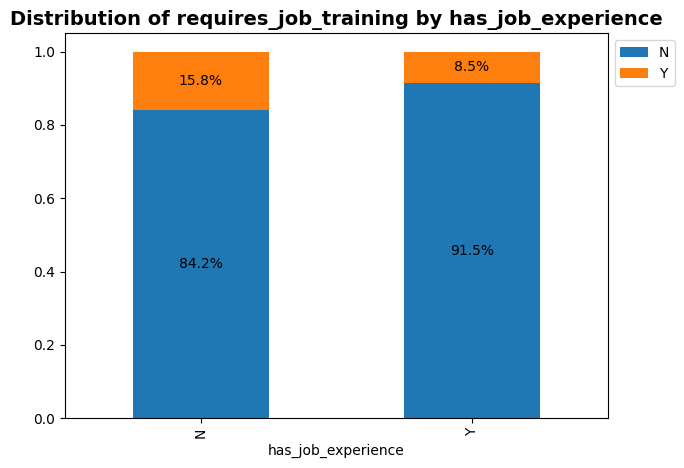

In [115]:
stacked_barplot(df, "has_job_experience", "requires_job_training")

*  91.5% of the employees who has job experience do not require job training and 8.5% of the employees require job training.
*  84.2% of the employees who don't have experience do not require job training and 15.8% of the employees require job training.

### Education of employee vs full time position

full_time_position        N      Y    All
education_of_employee                    
All                    2707  22773  25480
Master's               1738   7896   9634
Bachelor's              683   9551  10234
High School             206   3214   3420
Doctorate                80   2112   2192
------------------------------------------------------------------------------------------------------------------------


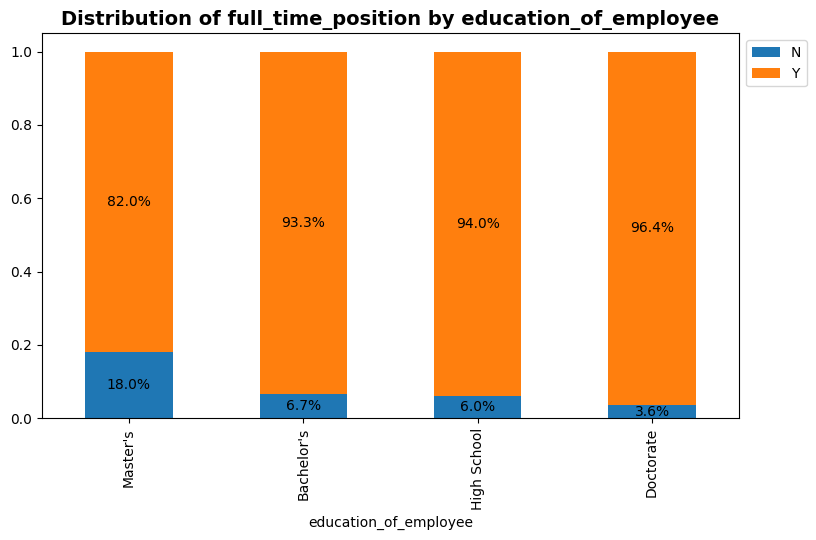

In [116]:
stacked_barplot(df, "education_of_employee", "full_time_position")

*  96.4% of Employees who have Doctorate degree have a full time position, while 3.6% employees have a part time position.
*  94.0% of Employees who have completed High school have a full time position, while 6.0% employees have a part time position.
*  93.3% of Employees who have Bachelor's degree has a full time position, while 6.7% employees have a part time position.
*  82.0% of Employees who have Master's degree has a full time position, while 18.0% employees have a part time position.

### Has job experience vs full time position

full_time_position     N      Y    All
has_job_experience                    
All                 2707  22773  25480
Y                   1410  13392  14802
N                   1297   9381  10678
------------------------------------------------------------------------------------------------------------------------


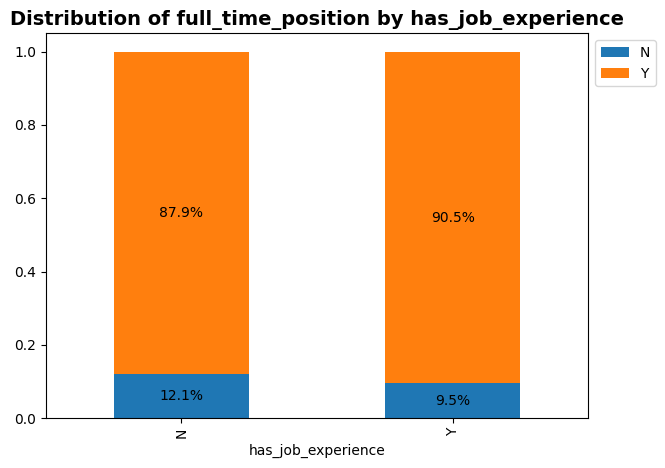

In [117]:
stacked_barplot(df, "has_job_experience", "full_time_position")

*  Full-time positions are dominant regardless of job experience status.
*  Employees with prior job experience have a higher proportion of full-time roles (90.5%) compared to those without experience (87.9%).
*  9.5% of employees with prior experience have a part time position.
*  Employees without job experience are slightly more likely to be in part time position(12.1%)

### Has job experience vs case status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


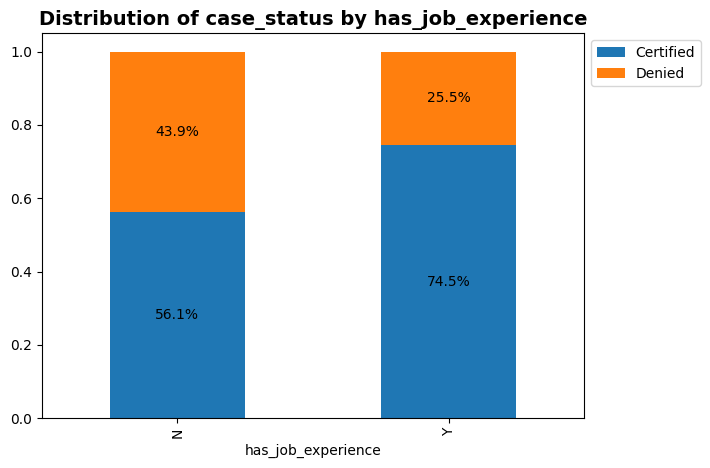

In [118]:
stacked_barplot(df, "has_job_experience", "case_status")

*  Among employees who have job experiences, 74.5% employee visa were certified and 25.5% visa were denied.
*  Among employees who did not have job experiences, 56.1 % employee visa were certified and 43.9% visa were denied.

### Continent vs case status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


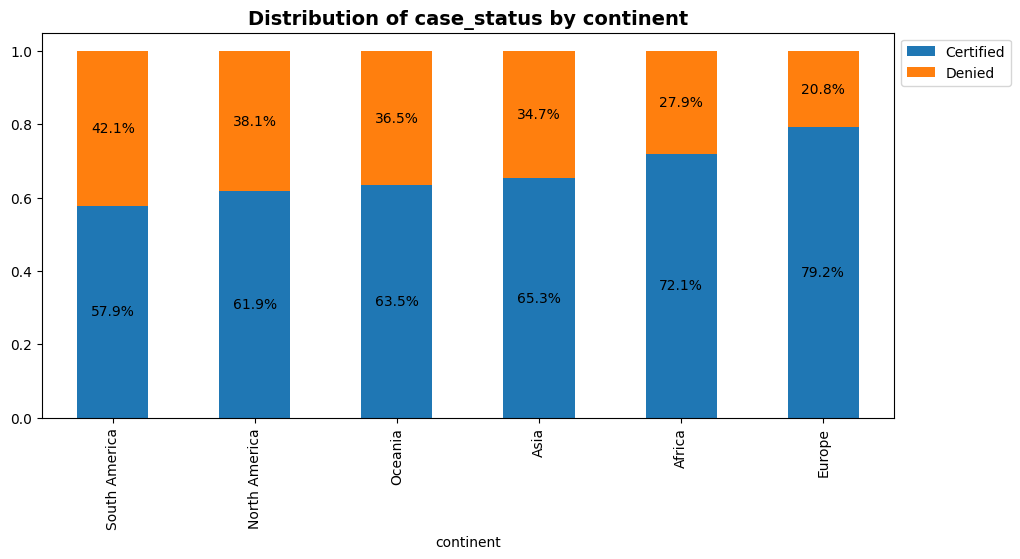

In [119]:
stacked_barplot(df, "continent", "case_status")

*  Among continents, Europe has the highest proportion(79.2%) of visa getting certified followed by Africa with 72.1%.
*  Asia and Oceania fall in the mid-range, with certification rates around 63–65%.
*  South America has the most visa denied rates with 42.1%, followed by North America with 38.1%.

### Education of employee vs case status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


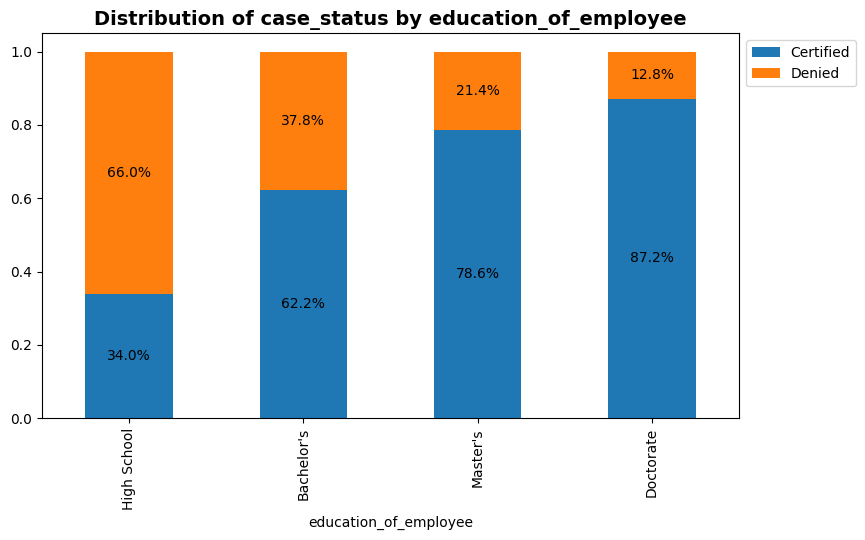

In [120]:
stacked_barplot(df, "education_of_employee", "case_status")

*  Employees who have completed Doctorate have higher change of visa getting certified(87.2%) followed by employees who completed Master's(78.6%).
*  Employee who have completed high school have a lower visa certified rate(34.0%) and a higher visa denial rate(66.0%).

### Full time position vs case status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


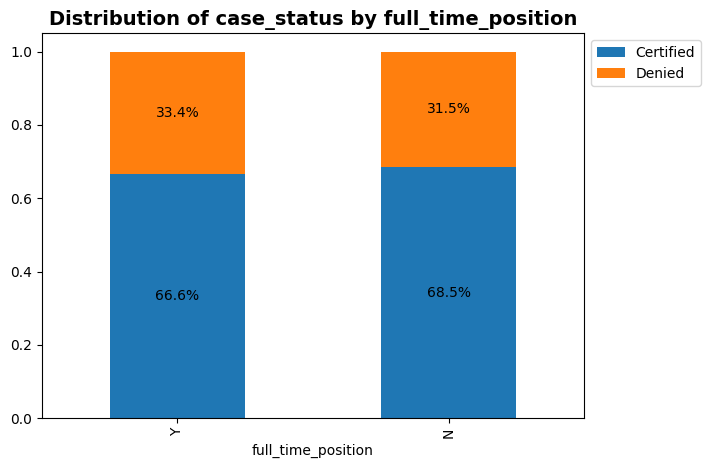

In [121]:
stacked_barplot(df, "full_time_position", "case_status")

*  For full time position, 66.6% visas are certified and 33.4% visas are denied.
*  For part-time position, 68.5% visas are certified and 31.5% visas are denied.


### Region of employment vs case status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


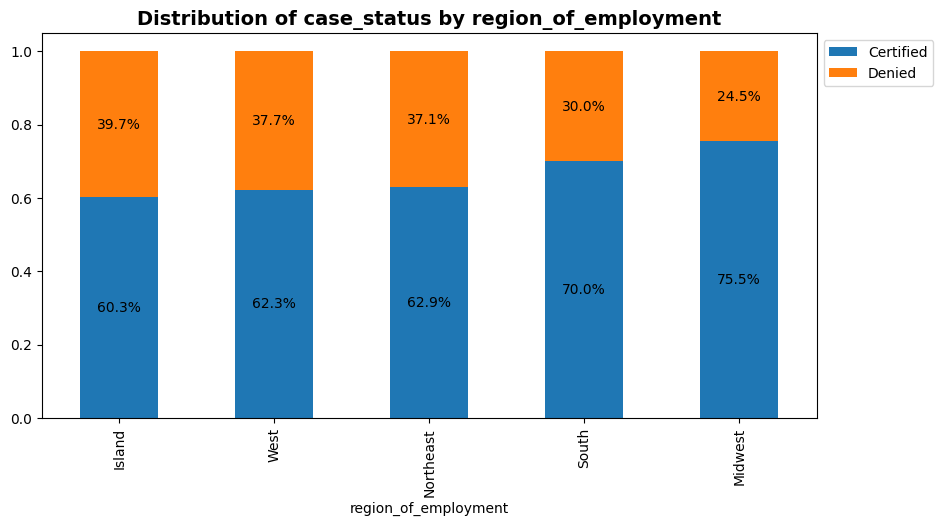

In [122]:
stacked_barplot(df, "region_of_employment", "case_status")

*  Midwest region has the highest certification rate(75.5%) and the lowest denial rate(24.5%), followed by South region with certification rate(70.0%) and denial rate(30.0).
*  West and Northeast region have almost same certification rate(63%) and denial rate(37%).
*  Island region has the highest denial rate(39.7%) when compared to other regions.
*  Almost in all the regions, visa certified proportion is higher to denial proportion.

### Requires job training vs case status

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


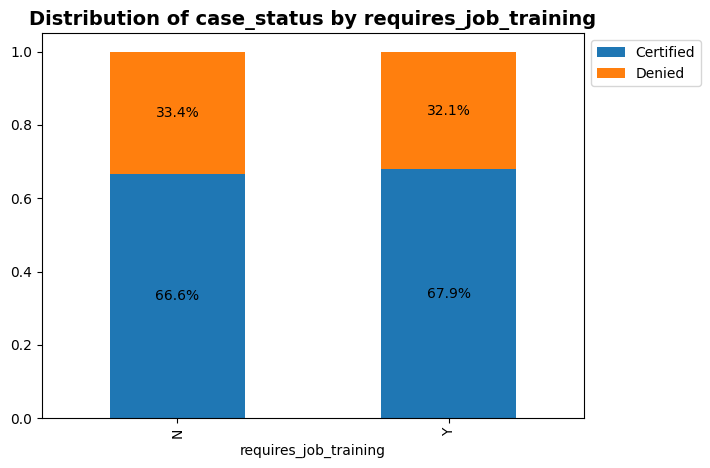

In [123]:
stacked_barplot(df, "requires_job_training", "case_status")

*  Employees who do not require job training has 66.7% visas certified and 33.4% visas denied.
*  Employees who require job training has 67.9% visas certified and 32.1% visas denied.
* Visa status is almost same for employees who required job training and who do not require job training.

### Distribution of Prevailing Wage by Case Status

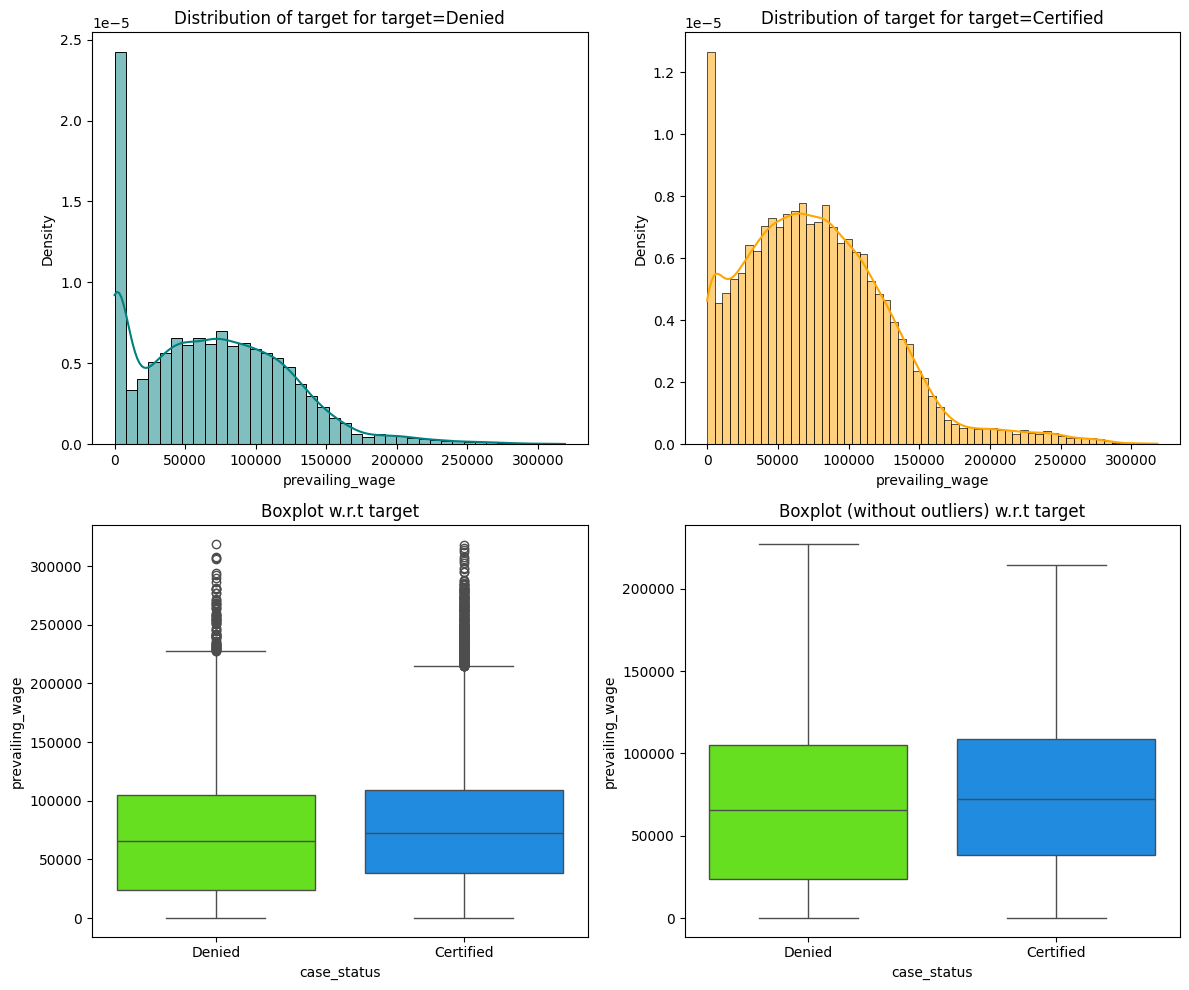

In [124]:
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

*  Certified applications tend to have higher prevailing wages than denied applications.
*  Both distributions are right-skewed, with long tails toward high wages, which is typical for wage data.
*  Even after removing outliers, the wage difference between Certified and Denied remains, confirming the pattern is not driven solely by extreme values.

# **Data Preprocessing**

## Duplicate value check

In [125]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in our dataset.

## Missing value treatment

In [126]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no missing values in our dataset. However, from our statistical summary we saw a data error, where minimum no of employees was -26. This is invalid. The invalid data imputation will be done after splitting the data.


Also, let's go and check for anomalies in other categorical data.

In [127]:
cat_var = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']
for col in cat_var:
    print(df[col].value_counts())
    print("-" * 30)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
------------------------------
case_status
Certified    17018
Denied

From the above information, we can observe that there are no anomalies present in other variables.

## Outlier check

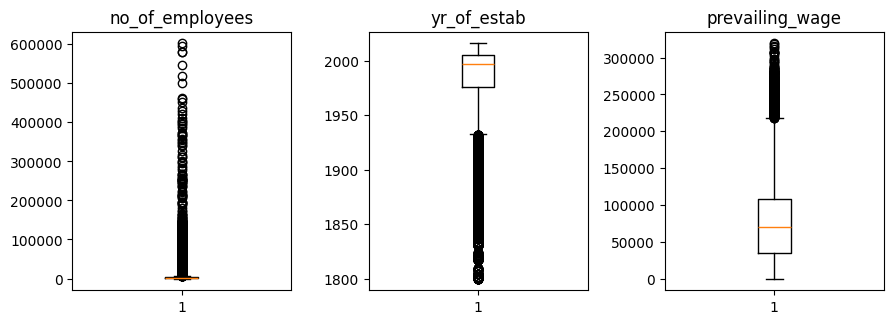

In [128]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 15))

for i, variable in enumerate(numeric_columns):
    plt.subplot(5, 4, i + 1)  # 5 rows, 4 columns
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

*  There are quite a few outliers in the data.
*  However, we will not treat them as they are proper values.

## Feature Engineering

In [129]:
# 1. Target Encoding
df['case_status'] = df['case_status'].replace({'Certified': 1, 'Denied': 0})

# 2. Drop Booking ID
df = df.drop(columns=['case_id'])

## Data preparation for modeling

*  We want to facilitate the visa process and recommend a suitable profile for the applicants for whom the visa should be certified or denied.
*  Before we proceed to build a model, we'll have to encode categorical features.
*  We'll split the data into training, validation and test to be able to evaluate the model that we build on the train data.

In [130]:
# checking the distribution of the target variable
df["case_status"].value_counts(normalize=True)

,proportion
case_status,
1,0.668
0,0.332


In [131]:
#Doing binary encoding
df['has_job_experience'] = df['has_job_experience'].replace({'Y': 1, 'N': 0})
df['requires_job_training'] = df['requires_job_training'].replace({'Y': 1, 'N': 0})
df['full_time_position'] = df['full_time_position'].replace({'Y': 1, 'N': 0})

#Doing label encoding
education_mapping = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3
}
df['education_of_employee'] = df['education_of_employee'].replace(education_mapping)

In [132]:
# separating the independent and dependent variables
X = df.drop(["case_status"], axis=1)
y = df["case_status"]

In [133]:
# Splitting data into training, validation and test set:

# first we split data into 2 parts, say temporary and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y
)

# then we split the temporary set into train and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=0, stratify=y_temp
)

In [134]:
print("Number of rows in train data =", X_train.shape)
print("Number of rows in validation data =", X_val.shape)
print("Number of rows in test data =", X_test.shape)

Number of rows in train data = (12740, 10)
Number of rows in validation data = (7644, 10)
Number of rows in test data = (5096, 10)


In [135]:
X_train.loc[X_train["no_of_employees"] < 0, "no_of_employees"] = np.nan
X_val.loc[X_val["no_of_employees"] < 0, "no_of_employees"]     = np.nan
X_test.loc[X_test["no_of_employees"] < 0, "no_of_employees"]   = np.nan

In [136]:
imp_median = SimpleImputer(strategy="median")

X_train.loc[:, "no_of_employees"] = (
    imp_median.fit_transform(X_train[["no_of_employees"]]).ravel()
)

X_val.loc[:, "no_of_employees"] = (
    imp_median.transform(X_val[["no_of_employees"]]).ravel()
)

X_test.loc[:, "no_of_employees"] = (
    imp_median.transform(X_test[["no_of_employees"]]).ravel()
)


In [137]:
print("Min value of employees in train:", X_train["no_of_employees"].min())
print("Min value of employees in validation:", X_val["no_of_employees"].min())
print("Min value of employees in test:", X_test["no_of_employees"].min())


Min value of employees in train: 12.0
Min value of employees in validation: 12.0
Min value of employees in test: 16.0


In [138]:
oneHotCols = ['continent', 'region_of_employment', 'unit_of_wage']
X_train = pd.get_dummies(X_train, columns=oneHotCols, drop_first=True)
X_val   = pd.get_dummies(X_val, columns=oneHotCols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=oneHotCols, drop_first=True)

# 4. Align
X_train, X_val  = X_train.align(X_val, axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, axis=1, fill_value=0)

X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)


In [139]:
X_train.head()

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
19653,1.000,1.000,0.000,20.000,2009.000,60740.180,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000
10021,0.000,0.000,0.000,4817.000,2000.000,52477.740,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000
18357,0.000,1.000,0.000,2405.000,2000.000,97330.770,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000
18408,0.000,0.000,0.000,1533.000,2014.000,51037.600,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000
20785,0.000,1.000,0.000,5576.000,2007.000,5811.290,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000


In [140]:
print("Number of rows and columns in train data after encoding =", X_train.shape)
print("Number of rows and columnsin validation data after encoding =", X_val.shape)
print("Number of rows and columns in test data after encoding=", X_test.shape)

Number of rows and columns in train data after encoding = (12740, 19)
Number of rows and columnsin validation data after encoding = (7644, 19)
Number of rows and columns in test data after encoding= (5096, 19)


# **Model building**

## Model evaluation criterion

**Model can make wrong predictions as:**
1. Predicting the visa application will be certified, but in reality, the application is denied.
2. Predicting the visa application will be denied, but in reality, the application is certified.

**Which case is more important?**
* If a visa is certified when it has to be denied, the wrong employee will get the job position while US citizens will miss the opportunity to work in that position.
*  If a visa is denied when it has to certified the US will lose a suitable employee that can contribute to the economy.
*  Both the cases are important.

**How to reduce this loss**
* OFLC would want F1 score to be maximized, the greater the F1 score, the higher the chances of minimizing false positives and false negatives.

**Let's define a function to output different metrics on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [141]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [142]:
def confusion_matrix_sklearn(model, predictors, target, title="Confusion Matrix"):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    title: title of the plot (default is "Confusion Matrix")
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show

##  Model Building

### Model Building - Original Data

In [143]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

train_performance_results = {}
val_performance_results = {}

for name, model in models:
    model.fit(X_train, y_train)

    perf_df_train = model_performance_classification_sklearn(model, X_train, y_train)
    perf_df_val = model_performance_classification_sklearn(model, X_val, y_val)

    train_performance_results[name] = perf_df_train.iloc[0].to_dict()
    val_performance_results[name] = perf_df_val.iloc[0].to_dict()

print("--- All Model Performance on Training Data ---")
all_train_perf_df = pd.DataFrame(train_performance_results).T
display(all_train_perf_df)

print("\n--- All Model Performance on Validation Data ---")
all_val_perf_df = pd.DataFrame(val_performance_results).T
display(all_val_perf_df)


--- All Model Performance on Training Data ---


,Accuracy,Recall,Precision,F1
dtree,1.000,1.000,1.000,1.000
Bagging,0.983,0.985,0.991,0.988
Random forest,1.000,1.000,1.000,1.000
GBM,0.756,0.879,0.782,0.828
Adaboost,0.737,0.883,0.761,0.818



--- All Model Performance on Validation Data ---


,Accuracy,Recall,Precision,F1
dtree,0.669,0.754,0.752,0.753
Bagging,0.708,0.794,0.774,0.784
Random forest,0.725,0.850,0.765,0.805
GBM,0.755,0.883,0.780,0.828
Adaboost,0.737,0.889,0.759,0.819


In [144]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.3f}, Validation Score: {:.3f}, Difference: {:.3f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

dtree: Training Score: 1.000, Validation Score: 0.753, Difference: 0.247
Bagging: Training Score: 0.988, Validation Score: 0.784, Difference: 0.204
Random forest: Training Score: 1.000, Validation Score: 0.805, Difference: 0.195
GBM: Training Score: 0.828, Validation Score: 0.828, Difference: -0.000
Adaboost: Training Score: 0.818, Validation Score: 0.819, Difference: -0.001


**Observations:**

1. Decision Tree(dtree)
    *  The model performs perfectly on training data but slightly lower in validation data which indicates of overfitting. The decision tree has memorized the training data but fails to generalize well.

2. Bagging(BaggingClassifier with Decision tree):
    *  Training score is high and the validation score is better than the decision tree. But the difference indicates of overfitting.

3. Random Forest(RandomForestClassifier)
    *  The model performs extremely well on train data but slightly poor on validation data indicating overfitting.

4. Gradient Boosting:
    *  The model training score is good, but not perfect. The validation score is very close to the training score which indicates that the model generalizes well and not overfitting.

5.  AdaBoost:
    *  Similar to GBM, AdaBoost model also has a non-perfect training score. But it is comparable to validation score. This model also generalizes well and do not overfit.


GBM and AdaBoost are clearly the best-performing models in terms of generalization and avoiding overfitting.

### Model Building - Oversampled Data

In [145]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of Certified 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 8509
Before Oversampling, counts of label 'Denied': 4231 

After Oversampling, counts of Certified 'Certified': 8509
After Oversampling, counts of label 'Denied': 8509 

After Oversampling, the shape of train_X: (17018, 19)
After Oversampling, the shape of train_y: (17018,) 



In [146]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

oversampled_train_performance_results = {}
oversampled_val_performance_results = {}

for name, model in models:
    model.fit(X_train_over, y_train_over)

    perf_df_train_over = model_performance_classification_sklearn(model, X_train_over, y_train_over)
    perf_df_val_over = model_performance_classification_sklearn(model, X_val, y_val)

    oversampled_train_performance_results[name] = perf_df_train_over.iloc[0].to_dict()
    oversampled_val_performance_results[name] = perf_df_val_over.iloc[0].to_dict()

print("--- All Model Performance on Oversampled Training Data ---")
all_oversampled_train_perf_df = pd.DataFrame(oversampled_train_performance_results).T
display(all_oversampled_train_perf_df)

print("\n--- All Model Performance on Oversampled Validation Data ---")
all_oversampled_val_perf_df = pd.DataFrame(oversampled_val_performance_results).T
display(all_oversampled_val_perf_df)


--- All Model Performance on Oversampled Training Data ---


,Accuracy,Recall,Precision,F1
dtree,1.000,1.000,1.000,1.000
Bagging,0.987,0.982,0.992,0.987
Random forest,1.000,1.000,1.000,1.000
GBM,0.812,0.866,0.782,0.822
Adaboost,0.792,0.865,0.755,0.806



--- All Model Performance on Oversampled Validation Data ---


,Accuracy,Recall,Precision,F1
dtree,0.655,0.734,0.746,0.740
Bagging,0.707,0.782,0.780,0.781
Random forest,0.721,0.834,0.768,0.800
GBM,0.752,0.872,0.782,0.825
Adaboost,0.738,0.877,0.765,0.818


In [147]:
print("\nTraining and Validation Performance Difference for oversampled data:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.3f}, Validation Score: {:.3f}, Difference: {:.3f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference for oversampled data:

dtree: Training Score: 1.000, Validation Score: 0.740, Difference: 0.260
Bagging: Training Score: 0.987, Validation Score: 0.781, Difference: 0.206
Random forest: Training Score: 1.000, Validation Score: 0.800, Difference: 0.200
GBM: Training Score: 0.822, Validation Score: 0.825, Difference: -0.003
Adaboost: Training Score: 0.806, Validation Score: 0.818, Difference: -0.011


**Observations:**

1. Decision Tree(dtree)

    *  The model performs perfectly on training data but slightly lower in validation data which indicates of overfitting. The decision tree has memorized the training data but fails to generalize well.

2. Bagging(BaggingClassifier with Decision tree):

    *  Training score is high and the validation score is lower than the decision tree. But the difference indicates of overfitting.

3.  Random Forest(RandomForestClassifier)

    *  The model performs well on train data but slightly poor on validation data indicating overfitting.

4. Gradient Boosting:

    * The model training score is good, but not perfect. The validation score is very close to the training score which indicates that the model generalizes well and not overfitting.

5. AdaBoost:

    * Similar to GBM, AdaBoost model also has a non-perfect training score. But it is comparable to validation score. This model also generalizes well and do not overfit.

Oversampling did not significantly help with DecisionTree, Bagging, Random forest with their generalization issues.

Though GBM and AdaBoost training score and validation score dropped slightly from the initial model, their performance remained stable and consistent and are clearly the best-performing models.

### Model Building - Undersampled Data

In [148]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [149]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 8509
Before Under Sampling, counts of label 'Denied': 4231 

After Under Sampling, counts of label 'Certified': 4231
After Under Sampling, counts of label 'Denied': 4231 

After Under Sampling, the shape of train_X: (8462, 19)
After Under Sampling, the shape of train_y: (8462,) 



In [150]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

undersampled_train_performance_results = {}
undersampled_val_performance_results = {}

for name, model in models:
    model.fit(X_train_un, y_train_un)

    perf_df_train_un = model_performance_classification_sklearn(model, X_train_un, y_train_un)
    perf_df_val_un = model_performance_classification_sklearn(model, X_val, y_val)

    undersampled_train_performance_results[name] = perf_df_train_un.iloc[0].to_dict()
    undersampled_val_performance_results[name] = perf_df_val_un.iloc[0].to_dict()

print("--- All Model Performance on Undersampled Training Data ---")
all_undersampled_train_perf_df = pd.DataFrame(undersampled_train_performance_results).T
display(all_undersampled_train_perf_df)

print("\n--- All Model Performance on Undersampled Validation Data ---")
all_undersampled_val_perf_df = pd.DataFrame(undersampled_val_performance_results).T
display(all_undersampled_val_perf_df)


--- All Model Performance on Undersampled Training Data ---


,Accuracy,Recall,Precision,F1
dtree,1.000,1.000,1.000,1.000
Bagging,0.979,0.967,0.990,0.979
Random forest,1.000,1.000,1.000,1.000
GBM,0.723,0.710,0.729,0.720
Adaboost,0.691,0.705,0.685,0.695



--- All Model Performance on Undersampled Validation Data ---


,Accuracy,Recall,Precision,F1
dtree,0.634,0.634,0.778,0.698
Bagging,0.651,0.622,0.811,0.704
Random forest,0.680,0.675,0.814,0.738
GBM,0.704,0.702,0.828,0.760
Adaboost,0.700,0.716,0.812,0.761


In [151]:
print("\nTraining and Validation Performance Difference of undersampled data:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.3f}, Validation Score: {:.3f}, Difference: {:.3f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference of undersampled data:

dtree: Training Score: 1.000, Validation Score: 0.698, Difference: 0.302
Bagging: Training Score: 0.979, Validation Score: 0.704, Difference: 0.275
Random forest: Training Score: 1.000, Validation Score: 0.738, Difference: 0.262
GBM: Training Score: 0.720, Validation Score: 0.760, Difference: -0.040
Adaboost: Training Score: 0.695, Validation Score: 0.761, Difference: -0.066


**Observations:**

1. Decision Tree(dtree)

    *  The model performs perfectly on training data but slightly  lower in validation data which indicates of overfitting. The decision tree has memorized the training data but fails to generalize well.

2. Bagging(BaggingClassifier with Decision tree):

    *  Training score is high and the validation score is better than the decision tree. But the difference indicates of overfitting.

3.  Random Forest(RandomForestClassifier)

    *  The model performs well on train data but slightly poor on validation data indicating overfitting.

4. Gradient Boosting:

    * The model training score(0.72) is significantly lower than (original:0.828, oversampled:0.822). Also, the validation score(0.76) dropped(original:0.828, oversampled:0.825). While the training and validation scores are close indicating generalization, the overall F1 scores have decreased.

5. AdaBoost:

    * The model training score(0.695) is significantly lower than (original:0.818, oversampled:0.806). Also, the validation score(0.761) dropped(original:0.819, oversampled:0.818). Similar to GBM, the training and validation scores are close indicating generalization, the overall F1 scores have decreased.

For all models, undersampling has led to a noticeable drop in F1 scores on both the training and validation sets. Undersampling appears to be less effective for this dataset compared to using the original imbalanced data or oversampled data.

## Model Performance Improvement using Hyperparameter Tuning

*  After building 15 models, it was observed that both the GBM and Adaboost models, trained on an original and oversampled dataset, exhibited strong performance on both the training and validation datasets.
*  Sometimes models might overfit after undersampling and oversampling, so it's better to tune the models to get a generalized performance.
*  We will tune these 4 models using the same data (original or oversampled) as we trained them on before.

### Tuning AdaBoostClassifier model with original data

In [152]:
%%time

# defining model, explicitly setting the base estimator to DecisionTreeClassifier
Model = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 1],
    "estimator__max_depth": [1, 2, 3],
    "estimator__min_samples_leaf": [5, 10, 20],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))


Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.2, 'estimator__min_samples_leaf': 10, 'estimator__max_depth': 3} with CV score=0.8196552860356674:
CPU times: user 1.75 s, sys: 239 ms, total: 1.99 s
Wall time: 1min 16s


In [153]:
tuned_adb = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=10,
        random_state=1
    ),
    n_estimators=20,
    learning_rate=0.2,
    random_state=1
)
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    min_samples_leaf=10,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=20, random_state=1)

In [154]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.740,0.921,0.748,0.825


In [155]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.738,0.923,0.746,0.825


*  After tuning hyperparameter, the f1 score of training and validation has increased slighlty from the original model.
*  Tuned Adaboost model is performing well and is able to generalize well.

### Tuning GradientBoostingClassifier model with original data

In [156]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "max_features": [0.5, 0.7, 1.0],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 20]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.01} with CV score=0.8231766173793762:
CPU times: user 4.98 s, sys: 484 ms, total: 5.47 s
Wall time: 7min 11s


In [157]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample= 0.9,
    n_estimators=150,
    min_samples_leaf=10,
    max_features=0.5,
    max_depth=4,
    learning_rate=0.01,
)
tuned_gbm1.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=4, max_features=0.5,
                           min_samples_leaf=10, n_estimators=150,
                           random_state=1, subsample=0.9)

In [158]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train, y_train
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.740,0.920,0.749,0.825


In [159]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.735,0.920,0.744,0.823


*  After tuning, Gradient Boosting is performing and generalizing well, but still have less f1 scores than Gradient boosting trained on original data.
*  Tuning didn't improve performance but the model is stable.

### Tuning AdaBoostClassifier model with oversampled data

In [160]:
%%time

# defining model, explicitly setting the base estimator to DecisionTreeClassifier
Model = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 1],
    "estimator__max_depth": [1, 2, 3],
    "estimator__min_samples_leaf": [5, 10, 20],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 1, 'estimator__min_samples_leaf': 5, 'estimator__max_depth': 3} with CV score=0.8071158150352853:
CPU times: user 3.25 s, sys: 345 ms, total: 3.6 s
Wall time: 2min 1s


In [161]:
tuned_adb1 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        random_state=1
    ),
    n_estimators=30,
    learning_rate=1,
    random_state=1
)
tuned_adb1.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    min_samples_leaf=5,
                                                    random_state=1),
                   learning_rate=1, n_estimators=30, random_state=1)

In [162]:
# Checking model's performance on training set
adb_train1 = model_performance_classification_sklearn(tuned_adb1, X_train_over, y_train_over)
adb_train1

,Accuracy,Recall,Precision,F1
0,0.804,0.851,0.778,0.813


In [163]:
# Checking model's performance on validation set
adb_val1 = model_performance_classification_sklearn(tuned_adb1, X_val, y_val)
adb_val1

,Accuracy,Recall,Precision,F1
0,0.742,0.857,0.779,0.816


*  AdaBoost tuned trained with oversampled data is performing slightly lesser than AdaBoost model trained with original data.
*  AdaBoost model tuned on oversampled data is performing well and is able to generalize well.

### Tuning GradientBoostingClassifier model with oversampled data

In [164]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "max_features": [0.5, 0.7, 1.0],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 20]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': 4, 'learning_rate': 0.05} with CV score=0.8199892606654104:
CPU times: user 8.44 s, sys: 806 ms, total: 9.25 s
Wall time: 12min 14s


In [165]:
tuned_gbm2 = GradientBoostingClassifier(
   random_state=1,
    subsample= 0.8,
    n_estimators=100,
    min_samples_leaf=5,
    max_features=0.7,
    max_depth=4,
    learning_rate=0.05
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, max_features=0.7,
                           min_samples_leaf=5, random_state=1, subsample=0.8)

In [166]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(
    tuned_gbm2, X_train_over, y_train_over
)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.812,0.868,0.781,0.822


In [167]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.755,0.874,0.784,0.827


*  Gradient Boosting model tuned with oversampled data is performing sligtly lesser than Gradient Boosting model tuned with original data in both training and validation performance.
*  Also, the model is performing lesser than Gradient Boosting model with original data.

## Model Comparison and Final Model Selection

### Training Performance comparison

In [168]:
# training performance comparison

# Get original GBM performance from the aggregated results (which is a Series)
original_gbm_train_perf = all_train_perf_df.loc['GBM']

# Create a dictionary of performance Series for each model
comparison_data_train = {
    "AdaBoost (Original Data) - Tuned": adb_train.iloc[0],
    "GBM (Original Data) - Untuned": original_gbm_train_perf,
    "GBM (Original Data) - Tuned": gbm1_train.iloc[0],
    "AdaBoost (Oversampled Data) - Tuned": adb_train1.iloc[0],
    "GBM (Oversampled Data) - Tuned": gbm2_train.iloc[0],
}

# Create a DataFrame from the dictionary, metrics will be the index and models the columns
models_train_comp_df = pd.DataFrame(comparison_data_train).T

print("Training performance comparison:")
display(models_train_comp_df)

Training performance comparison:


,Accuracy,Recall,Precision,F1
AdaBoost (Original Data) - Tuned,0.740,0.921,0.748,0.825
GBM (Original Data) - Untuned,0.756,0.879,0.782,0.828
GBM (Original Data) - Tuned,0.740,0.920,0.749,0.825
AdaBoost (Oversampled Data) - Tuned,0.804,0.851,0.778,0.813
GBM (Oversampled Data) - Tuned,0.812,0.868,0.781,0.822


*  In the training, the Gradient Boosting model trained on original data is performing well.
*  It is followed by AdaBoost model trained on original data and Gradient Boosting model tuned on original data.

### Validation Performance comparison

In [169]:
# Validation performance comparison

# Get original GBM performance from the aggregated results (which is a Series)
original_gbm_val_perf = all_val_perf_df.loc['GBM']

# Create a dictionary of performance Series for each model
comparison_data_val = {
    "AdaBoost (Original Data) - Tuned Validation": adb_val.iloc[0],
    "GBM (Original Data) - Untuned Validation": original_gbm_val_perf,
    "GBM (Original Data) - Tuned Validation": gbm_val.iloc[0],
    "AdaBoost (Oversampled Data) - Tuned Validation": adb_val1.iloc[0],
    "GBM (Oversampled Data) - Tuned Validation": gbm1_val.iloc[0],
}

# Create a DataFrame from the dictionary, metrics will be the index and models the columns
models_val_comp_df = pd.DataFrame(comparison_data_val).T

print("Validation performance comparison:")
display(models_val_comp_df)

Validation performance comparison:


,Accuracy,Recall,Precision,F1
AdaBoost (Original Data) - Tuned Validation,0.738,0.923,0.746,0.825
GBM (Original Data) - Untuned Validation,0.755,0.883,0.780,0.828
GBM (Original Data) - Tuned Validation,0.735,0.920,0.744,0.823
AdaBoost (Oversampled Data) - Tuned Validation,0.742,0.857,0.779,0.816
GBM (Oversampled Data) - Tuned Validation,0.735,0.920,0.744,0.823


*  In validation, Grading Boosting model with original data is performing well, followed by Grading Boosting model tuned with oversample data, AdaBoost model tuned with original data.
*  All the models are able to generalize well.

### Test Performance comparison

In [170]:
# The original GBM model is the fourth model in the 'models' list (index 3), and the model object is the second element (index 1)
original_gbm_model = models[3][1]
gbm_test = model_performance_classification_sklearn(original_gbm_model, X_test, y_test)
print("Original GBM (Untuned) Test:\n", gbm_test)

Original GBM (Untuned) Test:
    Accuracy  Recall  Precision    F1
0     0.706   0.703      0.831 0.762


In [171]:
# Checking the tuned AdaBoost model's performance on the test set (oversampled data)
adb1_test = model_performance_classification_sklearn(tuned_adb1, X_test, y_test)
print("AdaBoost (Oversampled Data) - Tuned Test:\n", adb1_test)

AdaBoost (Oversampled Data) - Tuned Test:
    Accuracy  Recall  Precision    F1
0     0.737   0.853      0.775 0.812


In [172]:
# Checking the tuned Gradient Boosting model's performance on the test set (oversampled data)
gbm2_test = model_performance_classification_sklearn(tuned_gbm2, X_test, y_test)
print("GBM (Oversampled Data) - Tuned Test:\n", gbm2_test)

GBM (Oversampled Data) - Tuned Test:
    Accuracy  Recall  Precision    F1
0     0.743   0.866      0.776 0.818


In [173]:
# Checking the tuned GBM model's performance on the test set (original data)
gbm1_test = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
print("GBM (Original Data) - Tuned Test:\n", gbm1_test)

GBM (Original Data) - Tuned Test:
    Accuracy  Recall  Precision    F1
0     0.731   0.919      0.740 0.820


In [174]:
# Checking the tuned AdaBoost model's performance on the test set (original data)
adb_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
print("AdaBoost (Original Data) - Tuned Test:\n", adb_test)

AdaBoost (Original Data) - Tuned Test:
    Accuracy  Recall  Precision    F1
0     0.733   0.921      0.741 0.822


In [175]:
# Test performance comparison

comparison_data_test = {
    "Original GBM (Untuned) Test": gbm_test.iloc[0],
    "AdaBoost (Original Data) - Tuned Test": adb_test.iloc[0],
    "GBM (Original Data) - Tuned Test": gbm1_test.iloc[0],
    "GBM (Oversampled Data) - Tuned Test": gbm2_test.iloc[0],
    "AdaBoost (Oversampled Data) - Tuned Test": adb1_test.iloc[0]
}

models_test_comp_df = pd.DataFrame(comparison_data_test).T

print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,Accuracy,Recall,Precision,F1
Original GBM (Untuned) Test,0.706,0.703,0.831,0.762
AdaBoost (Original Data) - Tuned Test,0.733,0.921,0.741,0.822
GBM (Original Data) - Tuned Test,0.731,0.919,0.740,0.820
GBM (Oversampled Data) - Tuned Test,0.743,0.866,0.776,0.818
AdaBoost (Oversampled Data) - Tuned Test,0.737,0.853,0.775,0.812


*  Though Grading Boosting model with original data was performing well in training and validation, the f1 score has dropped to 0.762 for unseen data. Also there is an increase in Precision and a decrease in Recall.
*  It seems that AdaBoost model tuned on original data is performing well on unseen data with highest f1-score and recall score.
*  The best model is AdaBoost model tuned on original data with 82.2% on the test set followed by Gradient Boosting model tuned on original data with high f1 score and recall score.


### Confusion matrix

Let us plot confusion matrix for our tuned AdaBoost model (original data) and see how it looks in training, validation and test sets.

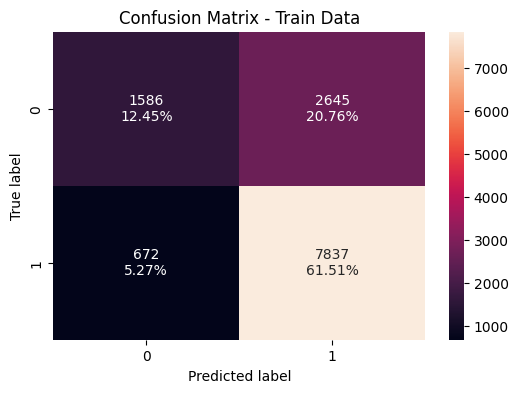

In [176]:
confusion_matrix_sklearn(
    tuned_adb,
    X_train,
    y_train,
    title="Confusion Matrix - Train Data"
)

True Positive(TP) - 7837

True Negative(TN) - 1586

False Positive(FP) - 2645

False Negative(FN) - 672

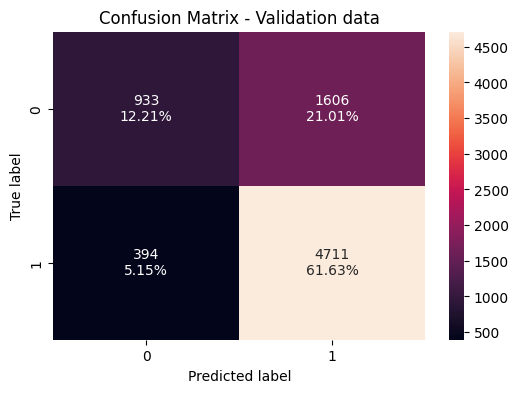

In [177]:
confusion_matrix_sklearn(
    tuned_adb,
    X_val,
    y_val,
    title="Confusion Matrix - Validation data"
)

True Positive(TP) - 4711

True Negative(TN) - 933

False Positive(FP) - 1606

False Negative(FN) - 394

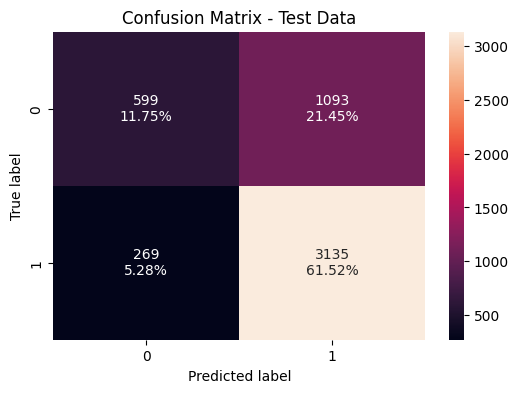

In [178]:
confusion_matrix_sklearn(
    tuned_adb,
    X_test,
    y_test,
    title="Confusion Matrix - Test Data"
)

True Positive(TP) - 3135

True Negative(TN) - 599

False Positive(FP) - 1093

False Negative(FN) - 269


### Precision-Recall curve

*  The PR curve allows comparison of model performance across all decision thresholds rather than at a single cutoff.

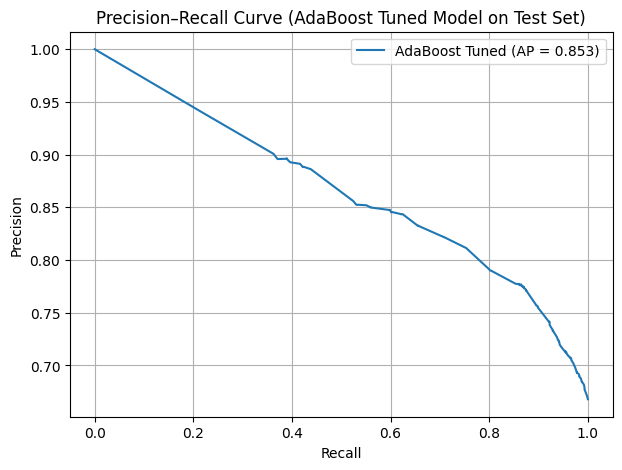

In [179]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get prediction probabilities for the positive class (Certified)
y_scores_adb = tuned_adb.predict_proba(X_test)[:, 1]

# Compute precision-recall pairs for different probability thresholds
precision_adb, recall_adb, _ = precision_recall_curve(y_test, y_scores_adb)

# Compute Average Precision (AP)
ap_adb = average_precision_score(y_test, y_scores_adb)

# Plot the Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall_adb, precision_adb, label=f"AdaBoost Tuned (AP = {ap_adb:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (AdaBoost Tuned Model on Test Set)")
plt.legend()
plt.grid(True)
plt.show()

 We'll plot Precision–Recall curve to compare Adaboost model tuned on original data and Gradient Boosting model tuned on original data because the dataset is imbalanced and precision and recall are more informative than accuracy.

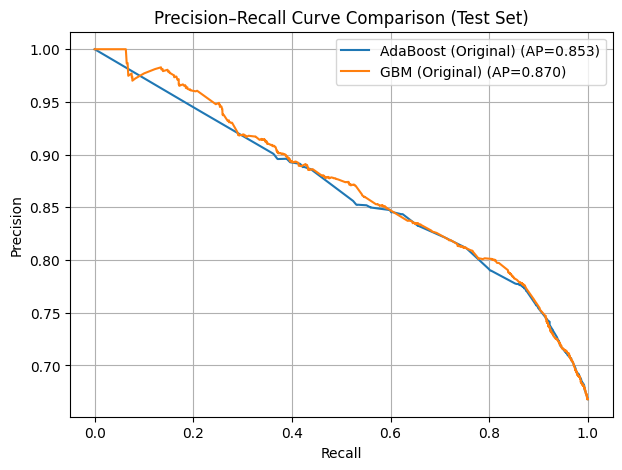

In [180]:
models = {
    "AdaBoost (Original)": tuned_adb,
    "GBM (Original)": tuned_gbm1
}

plt.figure(figsize=(7, 5))

for name, model in models.items():
    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (Test Set)")
plt.legend()
plt.grid(True)
plt.show()


*  While the tuned AdaBoost model achieves the highest F1-score on the test set at the selected classification threshold, the tuned Gradient Boosting model attains a higher average precision, indicating stronger overall precision–recall trade-offs across thresholds.
*  AdaBoost is best at the chosen threshold; GBM is better across thresholds.

### Feature Importance

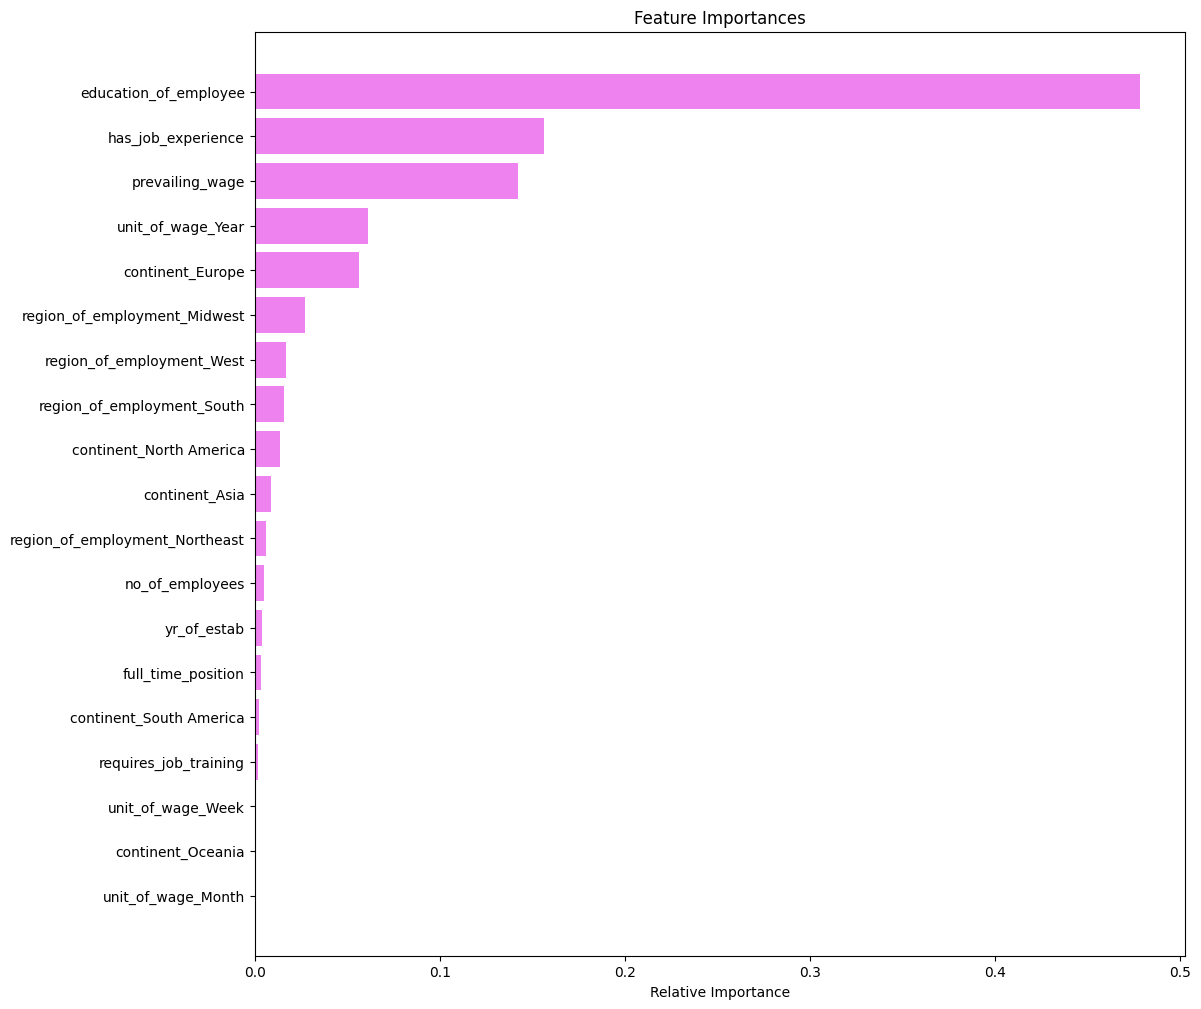

In [181]:
feature_names = X_train.columns
importances = tuned_gbm1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

*  We can see that , `education_of_employee`, `has_job_experience`, `prevailing_wage` and  are the most important features in predicting whether the visa will be certified or denied.

## Actionable Insights & Recommendations

Based on our comprehensive analysis and the selected Gradient Boosting model tuned on original data, here are key insights and practical recommendations for OFLC to facilitate the visa approval process and the drivers that significantly influences the case status of visa being Certified or Denied.

**Key Insights from Data Analysis and Model:**

**1.	Education Level is the Strongest Predictor**

The education level of the employee (education_of_employee) emerges as the most influential factor in visa certification decisions. Higher educational attainment is strongly associated with a greater likelihood of certification, indicating that skill level and qualifications play a central role in approval outcomes.

**2.	Prior Work Experience Significantly Improves Certification Probability**

Applicants with prior job experience (has_job_experience) are substantially more likely to receive certification. This suggests that demonstrated professional experience acts as an important credibility signal for visa approval.

**3.	Wage Level and Wage Structure Matter**

Higher prevailing wages (prevailing_wage) are positively associated with certification outcomes, reflecting the preference for higher-value or specialized roles. Additionally, jobs offering annual wage structures (unit_of_wage_Year) show stronger certification likelihood compared to other wage units, indicating stability and long-term employment intent.

**Recommendations**

**Prioritize Highly Educated and Experienced Applicants**

Given the strong influence of education and work experience, visa screening processes should prioritize candidates with higher educational qualifications and documented professional experience, particularly for roles requiring specialized skills.

**Align Wage Offerings with Certification Expectations**

Employers should ensure that wage offers are competitive and aligned with prevailing wage standards. Clearly structured annual salary offers may improve certification likelihood by signalling job stability and long-term employment intent.

**Focus Less on Geographic Bias**

Since geographic factors show limited predictive importance, decision-making processes should continue emphasizing applicant merit rather than regional attributes.

By leveraging data-driven insights from applicant qualifications, work experience, and wage characteristics, OFLC can improve decision consistency, reduce processing risk, and support fair, transparent, and skill-oriented visa approval policies.